# Notebook 05 — Forward system capacity maps (F5)

How much a sorbent tank delivers depends on where it is operated, not only on what
the sorbent is. This notebook sweeps the **full state** — pressure and temperature —
over the practical cryo-adsorption range for AX-21, holding the discharge endpoint
fixed, and draws system gravimetric and volumetric capacity across that plane. It
then asks the optimizer where the best achievable operating point is, which is what
makes a later comparison between two materials a comparison of materials rather
than of operating-point choices.

All physics lives in the `h2star` package. This notebook loads data, calls package
functions, prints what they return, and draws the figure. No model equation is
defined here.

**Read the capacities on this page as an optimistic bound.** Gate V3 is a documented
FAIL: the vessel, insulation and balance-of-plant block of the mass denominator is
light by a factor of about 4.2 against the HSECoE AX-21 anchor (`docs/validation_plan.md`).
The *shape* of the response across the plane is robust; the absolute level is not, and
the DOE target contour drawn below therefore sits further out in reality than it
appears here.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

from h2star import envelope, inverse, isotherm, system
from h2star.viz import plot_forward_maps

## Load the material, the engineering parameters and the targets

Every number comes from a committed YAML with its citation attached: the AX-21
modified Dubinin–Astakhov parameters (Richard, Bénard & Chahine 2009), the vessel,
insulation and balance-of-plant parameters, and the DOE system targets.

In [2]:
# Paths are written relative to the repository root: this notebook is meant to be
# executed with the repo root as the working directory. The fallback below also
# lets it run interactively from inside notebooks/.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path("..").resolve()

MATERIAL_YAML = REPO_ROOT / "data" / "materials" / "ax21.yaml"
ENGINEERING_YAML = REPO_ROOT / "data" / "engineering.yaml"
TARGETS_YAML = REPO_ROOT / "data" / "targets" / "doe_targets.yaml"

material = isotherm.Material.from_yaml(MATERIAL_YAML)
da = isotherm.ModifiedDA(material)
engineering = system.EngineeringParams.from_yaml(ENGINEERING_YAML)
targets = inverse.load_doe_targets(TARGETS_YAML, "2025")

print(f"material: {material.name}")
print(f"targets : {targets.label} - GC >= {targets.gc} kg/kg, "
      f"VC >= {targets.vc} kg/L")

material: AX-21
targets : DOE 2025 - GC >= 0.055 kg/kg, VC >= 0.04 kg/L


## Sweep the full state

Each node on the grid is a complete system: the tank is re-sized so that it delivers
the same 5.6 kg of usable hydrogen, and the full mass and volume budget is evaluated
at that size. Nothing is interpolated. The discharge endpoint is held at the baseline
5 bar / 160 K so the map isolates the effect of the full state.

In [3]:
P_full_grid = np.linspace(20.0e5, 200.0e5, 37)   # Pa (20-200 bar)
T_full_grid = np.linspace(60.0, 120.0, 31)       # K

grid = envelope.forward_map(
    material, da, engineering, P_full_grid, T_full_grid
)

print(f"grid: {grid['GC'].shape[0]} temperatures x {grid['GC'].shape[1]} pressures")
print(f"GC  : {np.nanmin(grid['GC']):.4f} - {np.nanmax(grid['GC']):.4f} kg/kg")
print(f"VC  : {np.nanmin(grid['VC']):.4f} - {np.nanmax(grid['VC']):.4f} kg/L")
print(f"V_in: {np.nanmin(grid['V_internal']):.4f} - "
      f"{np.nanmax(grid['V_internal']):.4f} m^3")

grid: 31 temperatures x 37 pressures
GC  : 0.0219 - 0.0831 kg/kg
VC  : 0.0059 - 0.0409 kg/L
V_in: 0.0974 - 0.6327 m^3


## Where does each target get crossed?

The gravimetric and volumetric targets are not crossed in the same place. Printing
the fraction of the mapped plane that clears each one separately shows which of the
two is the binding constraint for this material at this envelope — a question the
acceptability maps in notebook 06 then answer across material-property space.

In [4]:
gc_ok = np.nansum(grid["GC"] >= targets.gc)
vc_ok = np.nansum(grid["VC"] >= targets.vc)
both = np.nansum((grid["GC"] >= targets.gc) & (grid["VC"] >= targets.vc))
total = grid["GC"].size

print(f"nodes clearing GC >= {targets.gc} kg/kg : {gc_ok:5d} / {total}")
print(f"nodes clearing VC >= {targets.vc} kg/L  : {vc_ok:5d} / {total}")
print(f"nodes clearing both                     : {both:5d} / {total}")
print()
print("Binding constraint on this plane:",
      "volumetric" if vc_ok < gc_ok else "gravimetric")

nodes clearing GC >= 0.055 kg/kg :   764 / 1147
nodes clearing VC >= 0.04 kg/L  :     5 / 1147
nodes clearing both                     :     5 / 1147

Binding constraint on this plane: volumetric


## The best achievable operating point

Materials should be compared where each performs best, not at an arbitrary shared
envelope. The optimizer maximizes gravimetric capacity over full-state pressure and
temperature and the discharge temperature, with the delivery pressure held at the
5 bar fuel-cell floor.

`at_bound` is the honest part of the answer: if the optimum sits on the edge of the
search region then the bounds, not the physics, chose it, and the number should be
quoted with that in mind.

In [5]:
optimum = envelope.optimize_envelope(material, da, engineering, seed=0)

print(f"P_full  = {optimum.P_full / 1e5:8.2f} bar")
print(f"T_full  = {optimum.T_full:8.2f} K")
print(f"P_empty = {optimum.P_empty / 1e5:8.2f} bar  (fixed, delivery floor)")
print(f"T_empty = {optimum.T_empty:8.2f} K")
print()
print(f"GC      = {optimum.GC:.6f} kg/kg")
print(f"VC      = {optimum.VC:.6f} kg/L")
print(f"V_in    = {optimum.V_internal:.5f} m^3")
print()
print(f"on a search bound: {optimum.at_bound}")
print(f"system evaluations: {optimum.n_evaluations}")

P_full  =   200.00 bar
T_full  =    60.00 K
P_empty =     5.00 bar  (fixed, delivery floor)
T_empty =   200.00 K

GC      = 0.084342 kg/kg
VC      = 0.041799 kg/L
V_in    = 0.09550 m^3

on a search bound: ('P_full@upper', 'T_full@lower', 'T_empty@upper')
system evaluations: 3908


## Figure F5 — forward capacity maps

Filled contours are system capacity; the bold red line is the DOE 2025 target level
where it falls inside the mapped range.

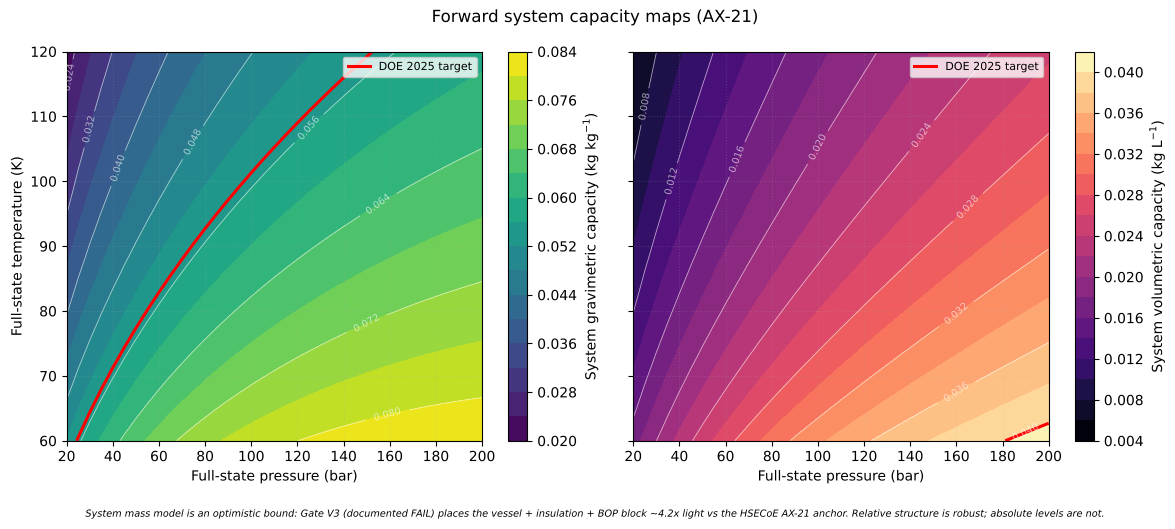

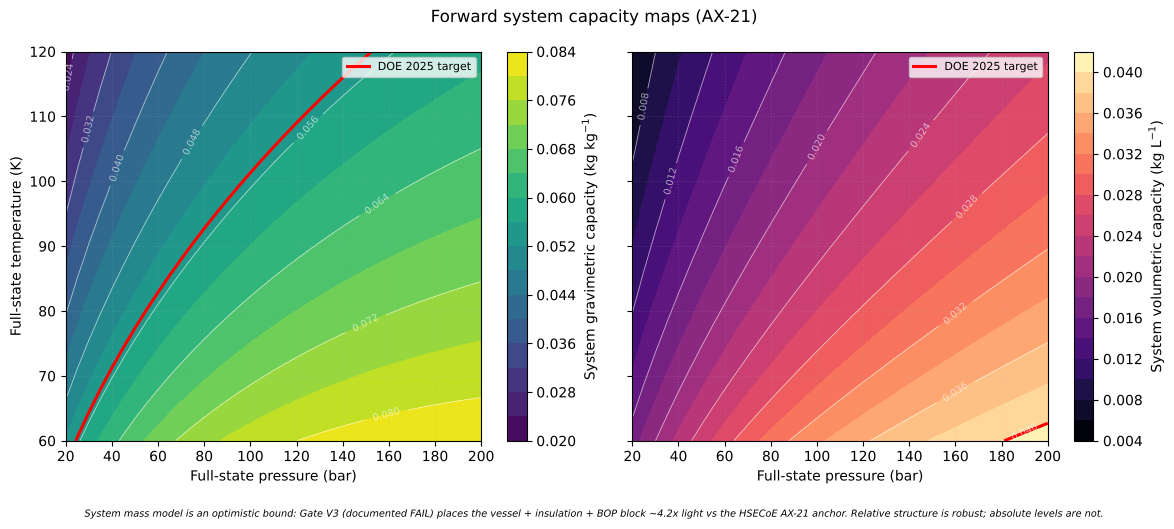

In [6]:
fig, (ax_gc, ax_vc) = plot_forward_maps(
    grid,
    targets=targets,
)

fig

The interpretation of these maps, and the limits on what they may be used to claim,
are written up in `docs/`. This notebook reproduces the numbers and the figure only.